# Практическая работа №1: Разведочный анализ данных киберфизической системы водоснабжения (SWaT)
#### СПбГЭТУ «ЛЭТИ», 2026 г.
#### Выполнила: Никитина Ангелина 2306



## 1. Постановка задачи и описание данных



**Цель работы:** Изучить методы визуализации для анализа данных, применить их к набору данных системы водоснабжения SWaT (Secure Water Treatment) и ответить на вопросы о выбросах, характере атак и ключевых атрибутах для классификации.

**Набор данных:** "merged.csv" — объединённые данные нормальной работы и кибератак на тестовом стенде водоочистки. Атрибуты включают показания датчиков (расходомеры FIT101, FIT201, FIT301 и др., уровнемеры LIT101, LIT301, анализаторы AIT201–AIT504) и состояния исполнительных устройств (насосы P101–P603, клапаны MV101–MV304). Целевая переменная – наличие атаки (столбец `Normal/Attack`), преобразована в бинарную `isAttack` (0 – норма, 1 – атака).

**Задача анализа:** На основе предоставленных данных необходимо провести разведочный анализ для выявления ключевых особенностей, которые помогут в дальнейшем решать задачу классификации атак. В рамках анализа требуется ответить на следующие вопросы:

1.  Присутствуют ли в данных выбросы, и если да, то в каких атрибутах?
2.  Наблюдается ли переходный период выхода системы на стационарный режим?
3.  Какие атрибуты наиболее информативны для решения задачи классификации атак и почему?


## 2. Загрузка и первичный анализ данных


In [1]:
# установка matplotlib
%pip install matplotlib --upgrade

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
import math

from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.ticker import FormatStrFormatter

Загружаем данные. 
В качестве примера используется реальный датасет SWaT (Secure Water Treatment), содержащий показания датчиков и состояния исполнительных устройств системы водоочистки. Данные включают как штатные (нормальные) периоды функционирования, так и интервалы с кибератаками.
Задача: проанализировать, как меняется поведение технологических параметров системы при реализации атаки.

In [3]:
df = pd.read_csv('merged.csv')

df.info() # посмотрим сколько признаков, есть ли пропущенные, а также их тип, распознан ли он правильно

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 53 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0    Timestamp     1441719 non-null  object 
 1   FIT101         1441719 non-null  float64
 2   LIT101         1441719 non-null  float64
 3    MV101         449919 non-null   float64
 4   P101           1441719 non-null  int64  
 5   P102           1441719 non-null  int64  
 6    AIT201        449919 non-null   float64
 7   AIT202         1441719 non-null  float64
 8   AIT203         1441719 non-null  float64
 9   FIT201         1441719 non-null  float64
 10   MV201         449919 non-null   float64
 11   P201          449919 non-null   float64
 12   P202          449919 non-null   float64
 13  P203           1441719 non-null  int64  
 14   P204          449919 non-null   float64
 15  P205           1441719 non-null  int64  
 16  P206           1441719 non-null  int64  
 17  DPIT301 

In [4]:
df.describe() 

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603
count,1.441719e+06,1.441719e+06,449919.000000,1.441719e+06,1.441719e+06,449919.000000,1.441719e+06,1.441719e+06,1.441719e+06,449919.000000,...,1.441719e+06,1.441719e+06,1441719.0,1.441719e+06,1.441719e+06,1.441719e+06,1.441719e+06,1441719.0,1.441719e+06,1441719.0
mean,1.806108e+00,5.931200e+02,1.665335,1.730916e+00,1.002168e+00,210.297302,8.431862e+00,3.395658e+02,1.791239e+00,1.691584,...,2.995530e-01,1.973482e+00,1.0,2.453681e+02,1.131493e+00,1.856421e+02,1.507692e-02,1.0,1.008294e+00,1.0
std,1.153932e+00,1.239325e+02,0.482323,4.434837e-01,4.650650e-02,35.157909,1.181389e-01,4.399908e+01,1.084655e+00,0.470611,...,4.981961e-02,1.606709e-01,0.0,3.829254e+01,3.001806e-01,2.961345e+01,1.522567e-01,0.0,9.069441e-02,0.0
min,0.000000e+00,1.206237e+02,0.000000,1.000000e+00,1.000000e+00,168.033800,6.000000e+00,2.853371e+02,0.000000e+00,0.000000,...,0.000000e+00,1.000000e+00,1.0,8.891951e+00,0.000000e+00,3.108177e+00,0.000000e+00,1.0,1.000000e+00,1.0
25%,0.000000e+00,5.087943e+02,1.000000,1.000000e+00,1.000000e+00,177.102000,8.357024e+00,3.211484e+02,0.000000e+00,1.000000,...,3.065689e-01,2.000000e+00,1.0,2.489906e+02,1.009195e+00,1.877724e+02,0.000000e+00,1.0,1.000000e+00,1.0
50%,2.487269e+00,5.268113e+02,2.000000,2.000000e+00,1.000000e+00,193.508100,8.380095e+00,3.300179e+02,2.444238e+00,2.000000,...,3.081062e-01,2.000000e+00,1.0,2.512977e+02,1.105309e+00,1.899353e+02,6.407587e-05,1.0,1.000000e+00,1.0
75%,2.588156e+00,6.957159e+02,2.000000,2.000000e+00,1.000000e+00,253.845200,8.450590e+00,3.341451e+02,2.452440e+00,2.000000,...,3.086186e-01,2.000000e+00,1.0,2.541656e+02,1.217441e+00,1.931876e+02,1.281517e-04,1.0,1.000000e+00,1.0
max,2.760145e+00,1.000000e+03,2.000000,2.000000e+00,2.000000e+00,267.719800,8.988273e+00,5.674699e+02,2.826899e+00,2.000000,...,3.170099e-01,2.000000e+00,1.0,2.646437e+02,3.668343e+00,2.006376e+02,1.802710e+00,1.0,2.000000e+00,1.0


## 3. Анализ числовых (вещественных) параметров

Для анализа выбраны пять ключевых вещественных параметров: FIT101 (расход на первом этапе), LIT101 (уровень воды в резервуаре), AIT201 (анализатор качества), AIT202 (второй анализатор), FIT201 (расход на втором этапе).



Сравним эффективность визуализации распределения данных с помощью ящика с усами и гистограммы на примере пяти вещественных признаков: FIT101, LIT101, AIT201, AIT202, FIT201. Эти признаки имеют разные диапазоны значений (например, FIT101 изменяется от 0 до 2.76, LIT101 – от 120 до 1000), поэтому для корректного сравнения их можно привести к единому масштабу (например, с помощью стандартизации). Далее целесообразно оценить распределение этих параметров в зависимости от целевой переменной – метки атаки (Normal/Attack), чтобы понять, как значения признаков отличаются в нормальном режиме и в условиях атаки.

In [ ]:
df.columns = df.columns.str.strip()

# Создаём числовую метку атаки (0 – норма, 1 – атака)
df['isAttack'] = (df['Normal/Attack'] == 'Attack').astype(int)

# Разделяем данные на нормальные и атаки
df_norm = df[df['isAttack'] == 0].copy()
df_anorm = df[df['isAttack'] == 1].copy()

labels_float = ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'FIT201']

df[labels_float].describe()

,FIT101,LIT101,AIT201,AIT202,FIT201
count,1.441719e+06,1.441719e+06,449919.000000,1.441719e+06,1.441719e+06
mean,1.806108e+00,5.931200e+02,210.297302,8.431862e+00,1.791239e+00
std,1.153932e+00,1.239325e+02,35.157909,1.181389e-01,1.084655e+00
min,0.000000e+00,1.206237e+02,168.033800,6.000000e+00,0.000000e+00
25%,0.000000e+00,5.087943e+02,177.102000,8.357024e+00,0.000000e+00
50%,2.487269e+00,5.268113e+02,193.508100,8.380095e+00,2.444238e+00
75%,2.588156e+00,6.957159e+02,253.845200,8.450590e+00,2.452440e+00
max,2.760145e+00,1.000000e+03,267.719800,8.988273e+00,2.826899e+00


3.1 Гистограммы распределения


In [ ]:
def hist_for_atribute_set(df, labels, ax, bin_num=25, df2=pd.DataFrame(), 
                          ylim=None, ylabel=None, y_scale='linear'):
      
    for i, col in enumerate(labels):
        ax[i].set_yscale(y_scale)   
        ax[i].tick_params(labelsize=10)
        ax[i].set_xlabel(col)
        
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['top'].set_visible(False)
        ax[i].grid()

        ax[i].hist(df[col], bin_num, density=False, color='#377eb8', alpha=.75) # синий 
        if not df2.empty:
            ax[i].hist(df2[col], bin_num, density=False, color='#e41a1c', alpha=.45) # красный

    len_labels = len(labels)
    len_ax = len(ax)
    if len_labels < len_ax:
        for a in ax[len_labels : len_labels + (len_ax - len_labels)]:
            a.axis('off')

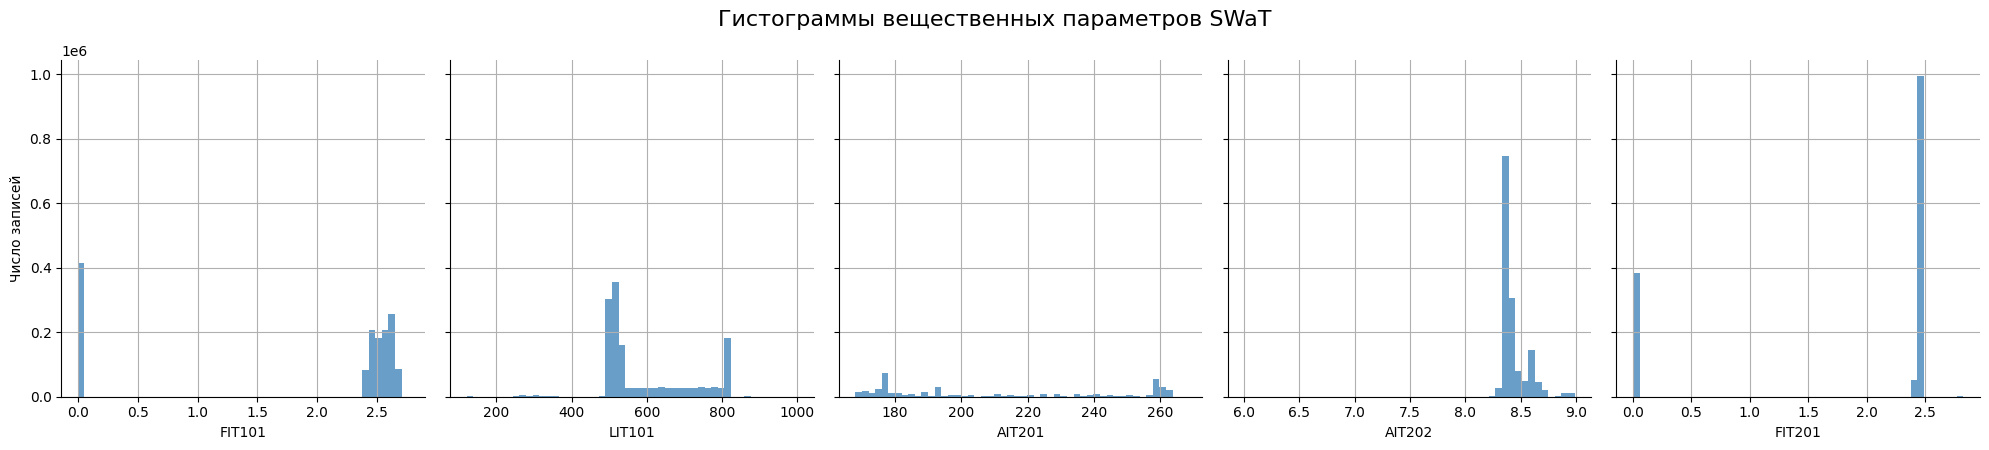

In [ ]:
labels_float = ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'FIT201']

fig, ax = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(20, 5))

hist_for_atribute_set(df, labels_float, ax, bin_num=50, y_scale='linear')

ax[0].set_ylabel('Число записей')
plt.suptitle('Гистограммы вещественных параметров SWaT', fontsize=16, y=.92)
fig.tight_layout(rect=[0, .03, 1, .95])
plt.show()


- **FIT101** – распределение бимодально: значительная часть значений сосредоточена около 2.0–2.5, однако присутствует и заметное количество нулевых значений. Это соответствует двум основным режимам работы (выключено/включено). При атаках доля нулей резко возрастает.
- **LIT101** – основная масса значений лежит в диапазоне 500–800, с длинным хвостом в сторону увеличения до 1000. В атаках медиана смещается выше 800, что указывает на аномальное повышение уровня.
- **AIT201** – значения компактно расположены в интервале 180–260 с несколькими пиками, отражающими дискретные режимы дозирования. При атаках распределение слегка сдвигается вниз.
- **AIT202** – очень узкое распределение около 8.0–8.5 (pH/проводимость) с редкими выбросами. В атаках весь диапазон смещается вверх, достигая 8.7.
- **FIT201** – аналогично FIT101, почти все значения близки к 2.5, но есть и нули. При атаках медиана падает до 0, что говорит о частом отключении потока.

На основе этих выводов определим дальнейшие шаги:

1. Сравним, можно ли сделать аналогичные заключения, используя `boxplot` (ящик с усами).
2. Оценим распределения значений в зависимости от меток атак (норма/атака) – построим гистограммы с наложением и столбчатые диаграммы для бинарных признаков.
3. Построим временные ряды (timelines), чтобы проследить динамику изменения параметров во времени и выявить характерные паттерны, сопровождающие атаки.

3.2 Ящики с усами (boxplot)


In [ ]:
def boxplot_for_atribute_set(df, labels, ax, ylim=None, ylabel=None):
  flierprops = dict(marker='o', markersize=3)
  
  for i, col in enumerate(labels):
    ax.boxplot(df[col], positions=[i + 1], flierprops=flierprops) # i + 1
    ax.tick_params(labelsize=10)
    ax.set_xticks(np.arange(len(labels)) + 1, labels)
            
    if ylim:
      ax.set_ylim(ylim)

    if ylabel:
      ax.set_ylabel(ylabel)

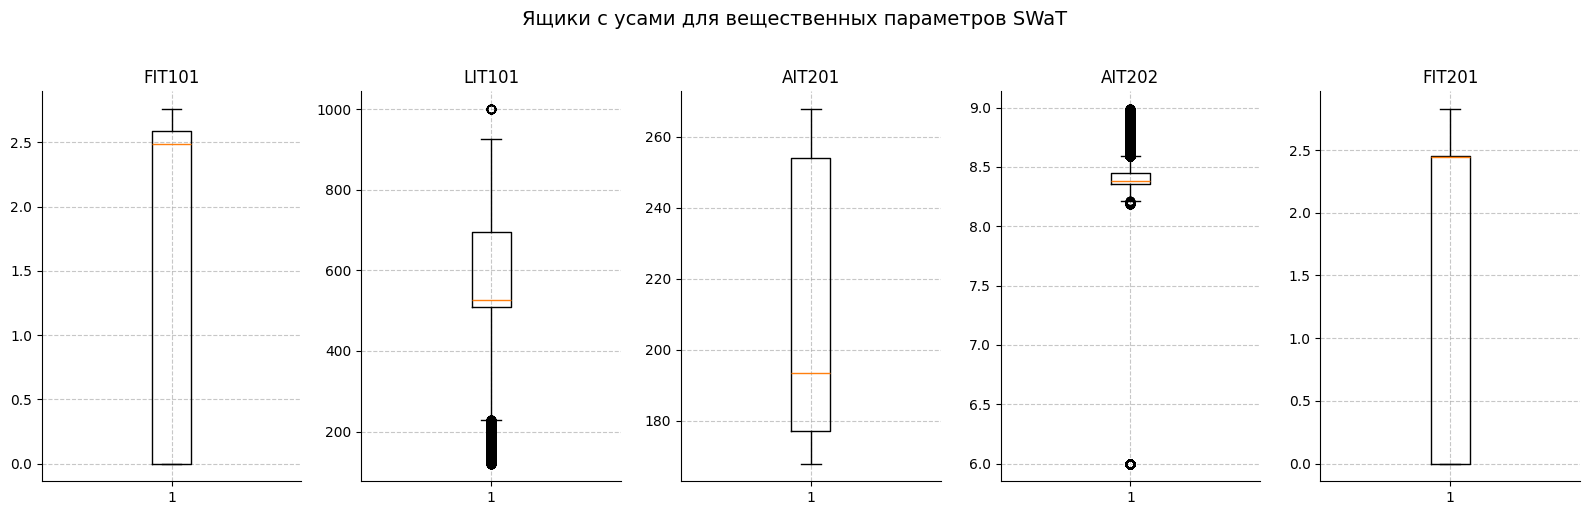

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for i, col in enumerate(labels_float):
    data = df[col].dropna()
    axes[i].boxplot(data)
    axes[i].set_title(col, fontsize=12)
    axes[i].grid(linestyle='--', alpha=0.7)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['top'].set_visible(False)

plt.suptitle('Ящики с усами для вещественных параметров SWaT', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Полученные графики подтверждают основные закономерности:

- **FIT101** – медиана в нормальных данных близка к 2.5, но из‑за большого количества нулей первый квартиль равен 0. «Усы» охватывают весь диапазон от 0 до 2.76, выбросы отсутствуют. При атаках медиана падает до 0, а третий квартиль поднимается до 2.46 – это отражает частое отключение насоса.
- **LIT101** – широкий разброс: от 500 до 700 в центральной коробке, с выбросами вниз (до 250) и вверх (до 900). В атаках весь ящик смещается выше (межквартильный интервал 626–813), что свидетельствует о нештатном повышении уровня.
- **AIT201** – компактное распределение с медианой около 200, выбросы отсутствуют. При атаках медиана незначительно снижается (до 193), форма распределения сохраняется.
- **AIT202** – очень узкая коробка (8.36–8.44), выбросы присутствуют как сверху, так и снизу. В атаках весь диапазон сдвигается вверх (8.53–8.61), выбросы уходят до 8.70.
- **FIT201** – картина, аналогичная FIT101: медиана 2.44 при наличии значительной доли нулей. При атаках медиана становится нулевой.

Из‑за существенно разных масштабов параметров на одном графике детали для узких распределений (AIT202) были бы неразличимы, поэтому были построены отдельные ящики для каждого признака, сохранив при этом возможность сравнения общей формы распределений.

Оценим распределение значений параметров с учётом значений целевого признака `Normal/Attack`. Построим столбчатую диаграмму для этого признака, чтобы понять, какова доля аномальных записей в наборе данных.

3.3 Гистограммы с разделением по метке атаки


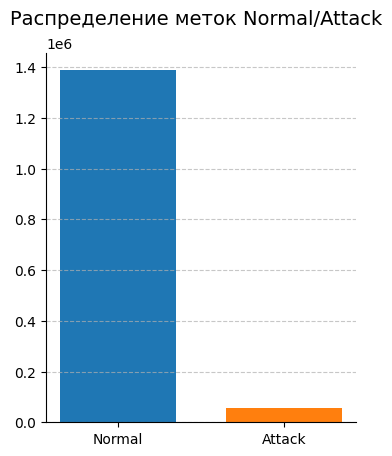

In [10]:
class_counts = df['isAttack'].value_counts().sort_index()

fig, ax = plt.subplots()
fig.set_figwidth(4)
plt.xticks(rotation=0)
plt.suptitle('Распределение меток Normal/Attack', fontsize=14, y=.97)
ax.bar(['Normal', 'Attack'], [class_counts[0], class_counts[1]], 
       width=0.7, color=['#1f77b4', '#ff7f0e'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Мы наблюдаем ярко выраженный дисбаланс классов: нормальные наблюдения преобладают над аномальными примерно в 25 раз. Это типично для задач обнаружения вторжений в промышленных системах, где атаки – редкие события. При построении моделей машинного обучения потребуется использовать специальные методы борьбы с дисбалансом.

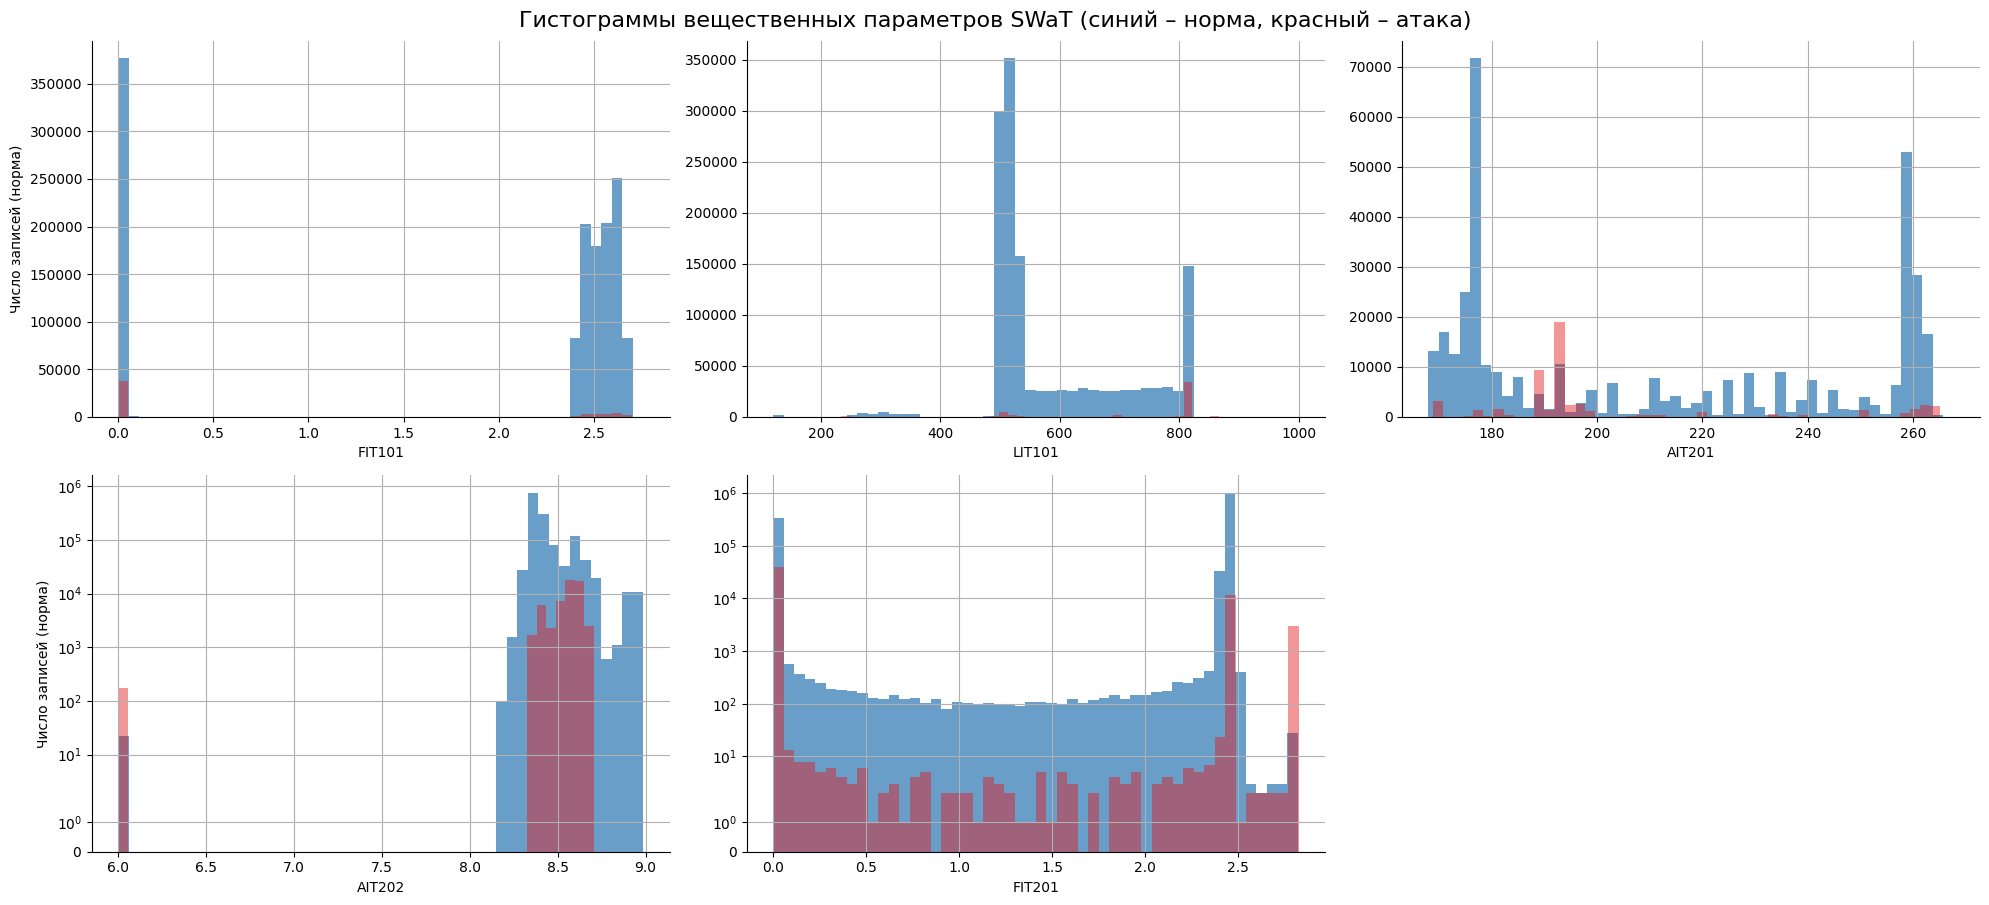

In [11]:
labels1 = ['FIT101', 'LIT101', 'AIT201']
labels2 = ['AIT202', 'FIT201']

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

hist_for_atribute_set(df_norm, labels1, ax[0], bin_num=50, df2=df_anorm, y_scale='linear')

hist_for_atribute_set(df_norm, labels2, ax[1], bin_num=50, df2=df_anorm, y_scale='symlog')

ax[0, 0].set_ylabel('Число записей (норма)')
ax[1, 0].set_ylabel('Число записей (норма)')

plt.suptitle('Гистограммы вещественных параметров SWaT (синий – норма, красный – атака)', fontsize=16, y=.93)
fig.tight_layout(rect=[0, .03, 1, .95])
plt.show()


На гистограммах представлены распределения пяти физических параметров для нормальных данных (синий) и данных с атаками (красный).

- **FIT101** – расход на первом этапе. В нормальном режиме распределение бимодально: 27% значений – нули (насос выключен), 72% – значения выше 2.0 (насос включён). При атаках доля нулей резко возрастает до 69%, а доля высоких значений падает до 31%. Это свидетельствует о том, что атаки часто приводят к отключению насоса или имитации его выключенного состояния.

- **LIT101** – уровень воды в резервуаре. В норме основная масса значений лежит между 500 и 700, медиана – 525.8. При атаках медиана подскакивает до 813.0, а весь диапазон смещается вверх. Это указывает на аномальное повышение уровня, возможно, из-за неправильной работы клапанов или насосов.

- **AIT201** – анализатор качества. В норме распределение компактное, медиана 199.7, межквартильный интервал 176–257. При атаках медиана незначительно снижается до 193.0, форма распределения сохраняется. Этот параметр слабо чувствителен к атакам.

- **AIT202** – ещё один анализатор с очень узким диапазоном. В норме 50% значений лежат между 8.36 и 8.44, медиана 8.38. При атаках весь диапазон сдвигается вверх (медиана 8.58, межквартильный интервал 8.53–8.61), что может быть следствием аномального изменения химического состава воды.

- **FIT201** – расход на втором этапе. Аналогично FIT101: в норме 25% нулей, 75% – высокие значения. При атаках доля нулей возрастает до 72%, доля высоких падает до 27%. Это также указывает на частое отключение потока в условиях атаки.

Таким образом, гистограммы наглядно демонстрируют, что параметры FIT101, FIT201 и LIT101 наиболее сильно реагируют на атаки, тогда как AIT201 и AIT202 изменяются слабее, но тоже дают полезную информацию.

## 4. Временные ряды вещественных параметров



Для визуализации динамики во времени используется вспомогательная функция plot_state_as_color, выделяющая периоды атаки цветным фоном.



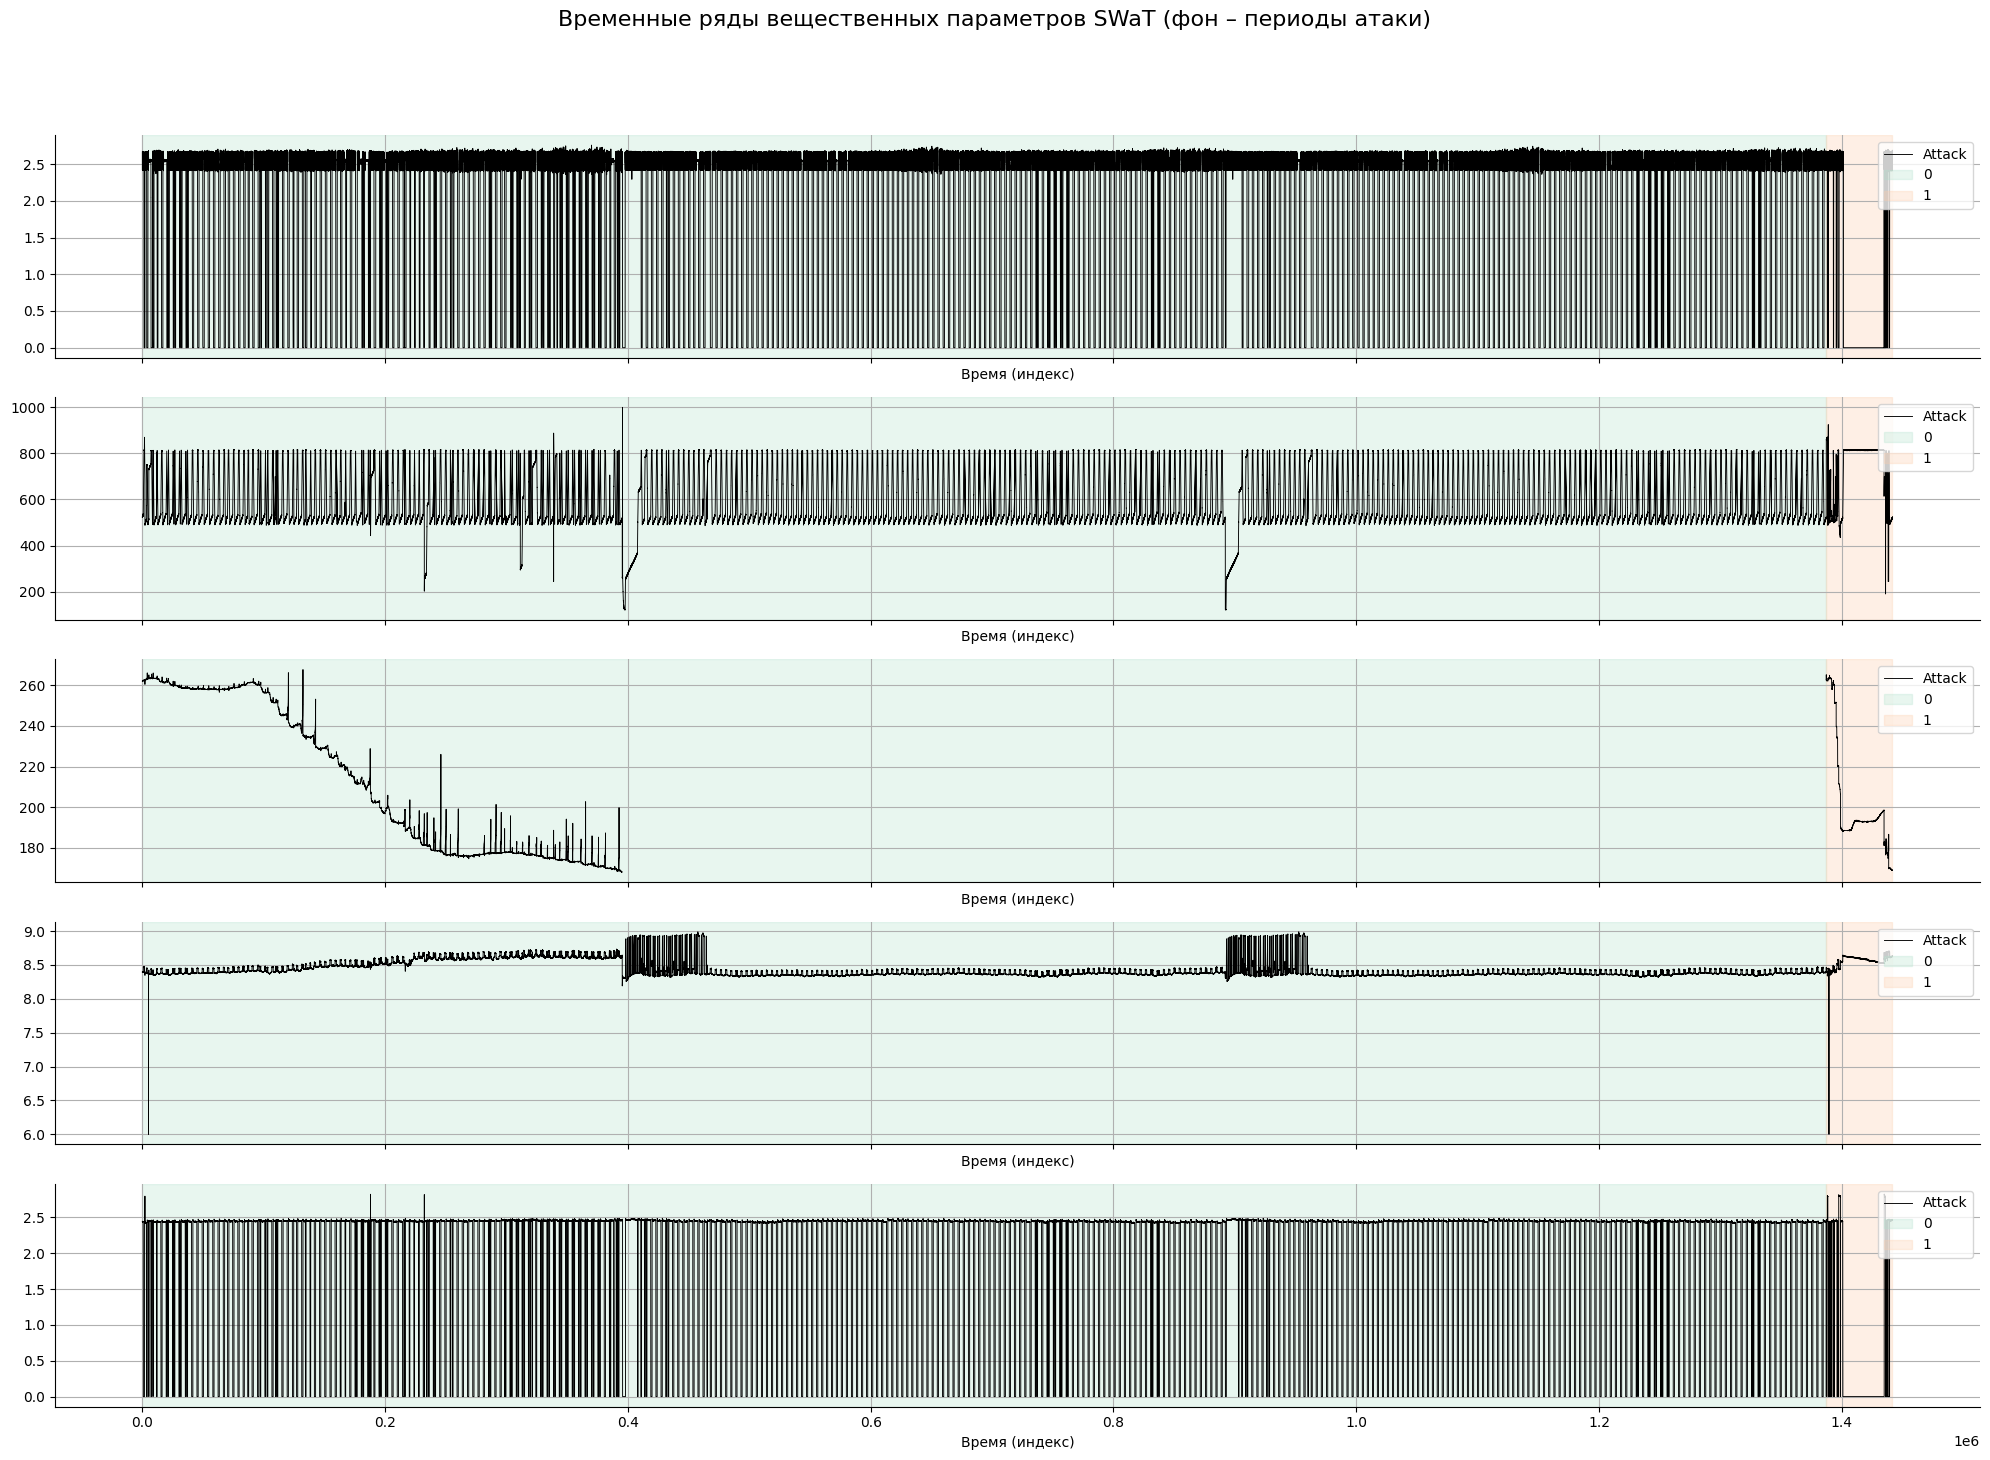

In [12]:
def plot_state_as_color(x_data, state_data, axis, add_labels=True):
    cmap = mpl.colormaps['Pastel2']
    state_current = state_data.iloc[0] if hasattr(state_data, 'iloc') else state_data[0]
    span_left = x_data[0]
    state_encountered = []
    for span_right, state_next in zip(x_data, state_data):
        if state_current != state_next:
            label = None
            if state_current not in state_encountered:
                state_encountered.append(state_current)
            if add_labels:
                label = state_current
            color = cmap.colors[state_encountered.index(state_current)]
            axis.axvspan(span_left, span_right, color=color, alpha=0.3, label=label)
            span_left = span_right
            state_current = state_next
    if state_current not in state_encountered:
        state_encountered.append(state_current)
        label = state_current if add_labels else None
    else:
        label = None
    color = cmap.colors[state_encountered.index(state_current)]
    axis.axvspan(span_left, span_right, color=color, alpha=0.3, label=label)

def lineplot_for_atribute_set(df, df_x, df_background, labels, ax, ylim=None, ylabel=None):
    for i, col in enumerate(labels):
        ax[i].set_xlabel('Время (индекс)')
        ax[i].plot(df_x, df[col], color='black', linewidth=0.65, label='Attack')
        plot_state_as_color(x_data=df_x, state_data=df_background, axis=ax[i])
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['top'].set_visible(False)
        ax[i].legend(loc='upper right')
        ax[i].grid()

x_axis = np.arange(len(df))
labels_ts = ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'FIT201']

fig, ax = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(20, 15))
lineplot_for_atribute_set(df, x_axis, df['isAttack'], labels_ts, ax)
fig.suptitle('Временные ряды вещественных параметров SWaT (фон – периоды атаки)', fontsize=16, y=1.00)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [13]:
attack_mask = df['isAttack'].values
changes = np.diff(attack_mask, prepend=0)          # 1 = начало атаки, -1 = конец атаки
attack_starts = np.where(changes == 1)[0]
attack_ends = np.where(changes == -1)[0]

if len(attack_ends) < len(attack_starts):
    attack_ends = np.append(attack_ends, len(df)-1)

attack_durations = attack_ends - attack_starts

print("=== Характеристики периодов атаки ===")
print(f"Количество отдельных периодов атаки: {len(attack_starts)}")
print(f"Минимальная длительность атаки (число шагов): {attack_durations.min()}")
print(f"Максимальная длительность атаки: {attack_durations.max()}")
print(f"Средняя длительность атаки: {attack_durations.mean():.1f}")
print(f"Медианная длительность атаки: {np.median(attack_durations):.1f}")
print(f"Суммарное количество шагов под атакой: {attack_durations.sum()}")

features = ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'FIT201']
print("\n=== Средние значения параметров в нормальных условиях и во время атак ===")
for col in features:
    norm_mean = df[df['isAttack']==0][col].mean()
    attack_mean = df[df['isAttack']==1][col].mean()
    print(f"{col}: норма = {norm_mean:.3f}, атака = {attack_mean:.3f}, "
          f"изменение = {attack_mean - norm_mean:.3f}")

=== Характеристики периодов атаки ===
Количество отдельных периодов атаки: 1
Минимальная длительность атаки (число шагов): 54620
Максимальная длительность атаки: 54620
Средняя длительность атаки: 54620.0
Медианная длительность атаки: 54620.0
Суммарное количество шагов под атакой: 54620

=== Средние значения параметров в нормальных условиях и во время атак ===
FIT101: норма = 1.846, атака = 0.788, изменение = -1.058
LIT101: норма = 587.832, атака = 727.418, изменение = 139.586
AIT201: норма = 211.412, атака = 202.227, изменение = -9.185
AIT202: норма = 8.427, атака = 8.546, изменение = 0.119
FIT201: норма = 1.835, атака = 0.689, изменение = -1.145


Все атаки в датасете сосредоточены в одном непрерывном интервале длительностью 54 620 шагов. Визуально и статистически выделяются следующие закономерности:

- **FIT101** и **FIT201** – во время атаки их средние значения резко падают (с ~1.84 до ~0.79 и с ~1.83 до ~0.69 соответственно), что соответствует частому отключению потока.
- **LIT101** – уровень воды в резервуаре устойчиво повышается (с ~588 до ~727), что может указывать на блокировку слива или избыточную подачу.
- **AIT202** – незначительно, но стабильно растёт (с ~8.43 до ~8.55), сигнализируя об изменении химического состава.
- **AIT201** – практически не реагирует на атаку (изменение среднего всего на –9.2, визуально колебания остаются в тех же пределах).

Таким образом, наиболее информативными для обнаружения атак являются параметры расхода (FIT101, FIT201) и уровня (LIT101), тогда как анализаторы дают менее выраженный, но тоже полезный сигнал.

## 5. Анализ логических параметров

5.1 Столбчатые диаграммы распределения состояний


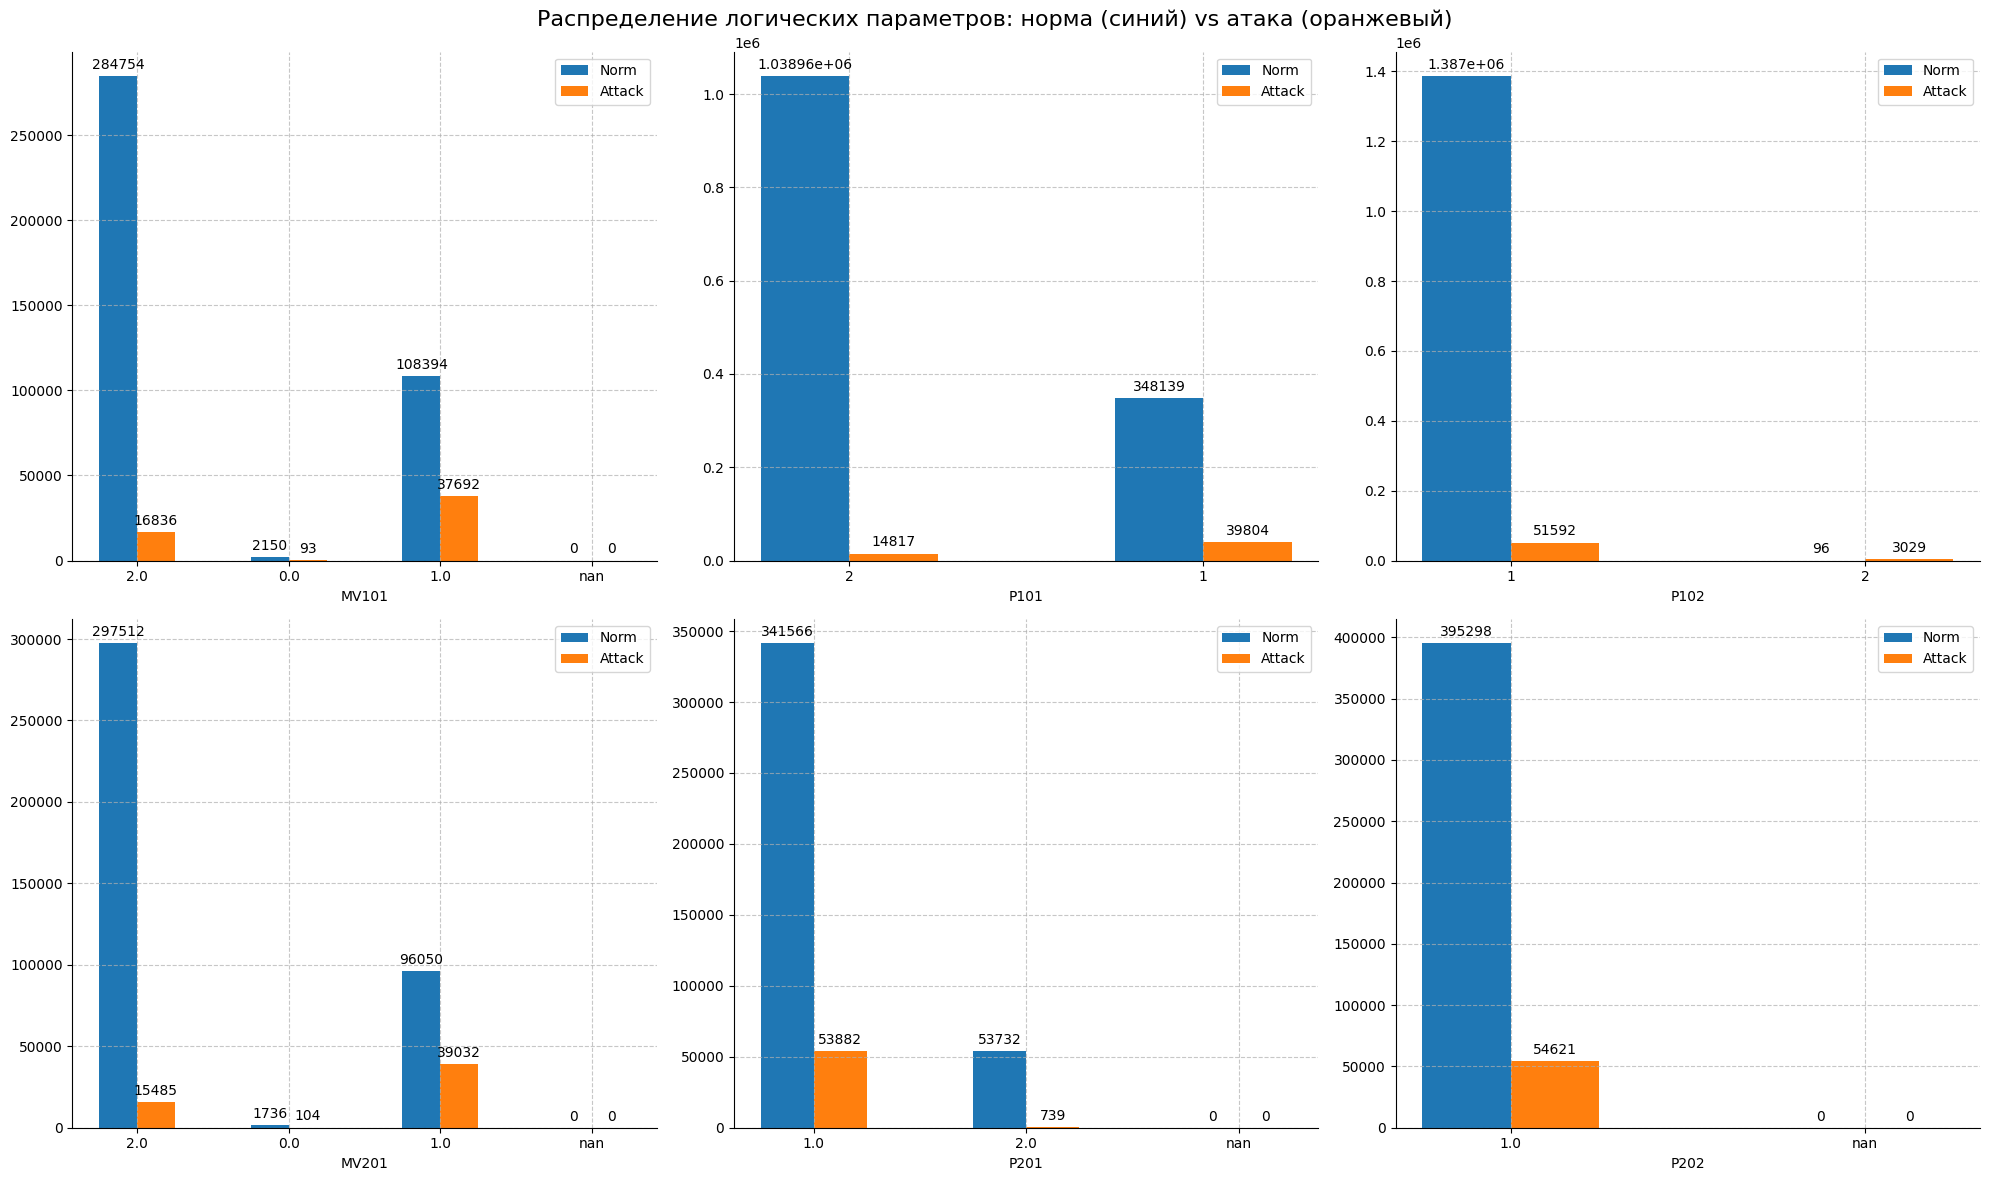

In [14]:
def bar_for_atribute_set(df1, df2, label, ax, y_scale='linear'):
    d = dict()
    d['Norm'] = []
    d['Attack'] = [] 

    attr_values = df1[label].unique()  # значения признака (например, 1, 2)
    x = np.arange(len(attr_values))
    width = 0.25
    multiplier = 0

    for attr_val in attr_values:
        attr_val_num_norm = df1[df1[label] == attr_val].shape[0]
        attr_val_num_attack = df2[df2[label] == attr_val].shape[0]
        d['Norm'].append(attr_val_num_norm)
        d['Attack'].append(attr_val_num_attack)

    for attr, val in d.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, val, width, label=str(attr))
        ax.bar_label(rects, padding=3)
        multiplier += 1

    ax.set_yscale(y_scale)
    ax.set_xticks(x + width / 2, attr_values)
    ax.set_xlabel(label)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.7)
    ax.legend()

bool_labels1 = ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202']

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
fig.suptitle('Распределение логических параметров: норма (синий) vs атака (оранжевый)', fontsize=16, y=0.98)

axes = ax.flatten()
for i, col in enumerate(bool_labels1):
    bar_for_atribute_set(df_norm, df_anorm, col, axes[i], y_scale='linear')

plt.tight_layout()
plt.show()

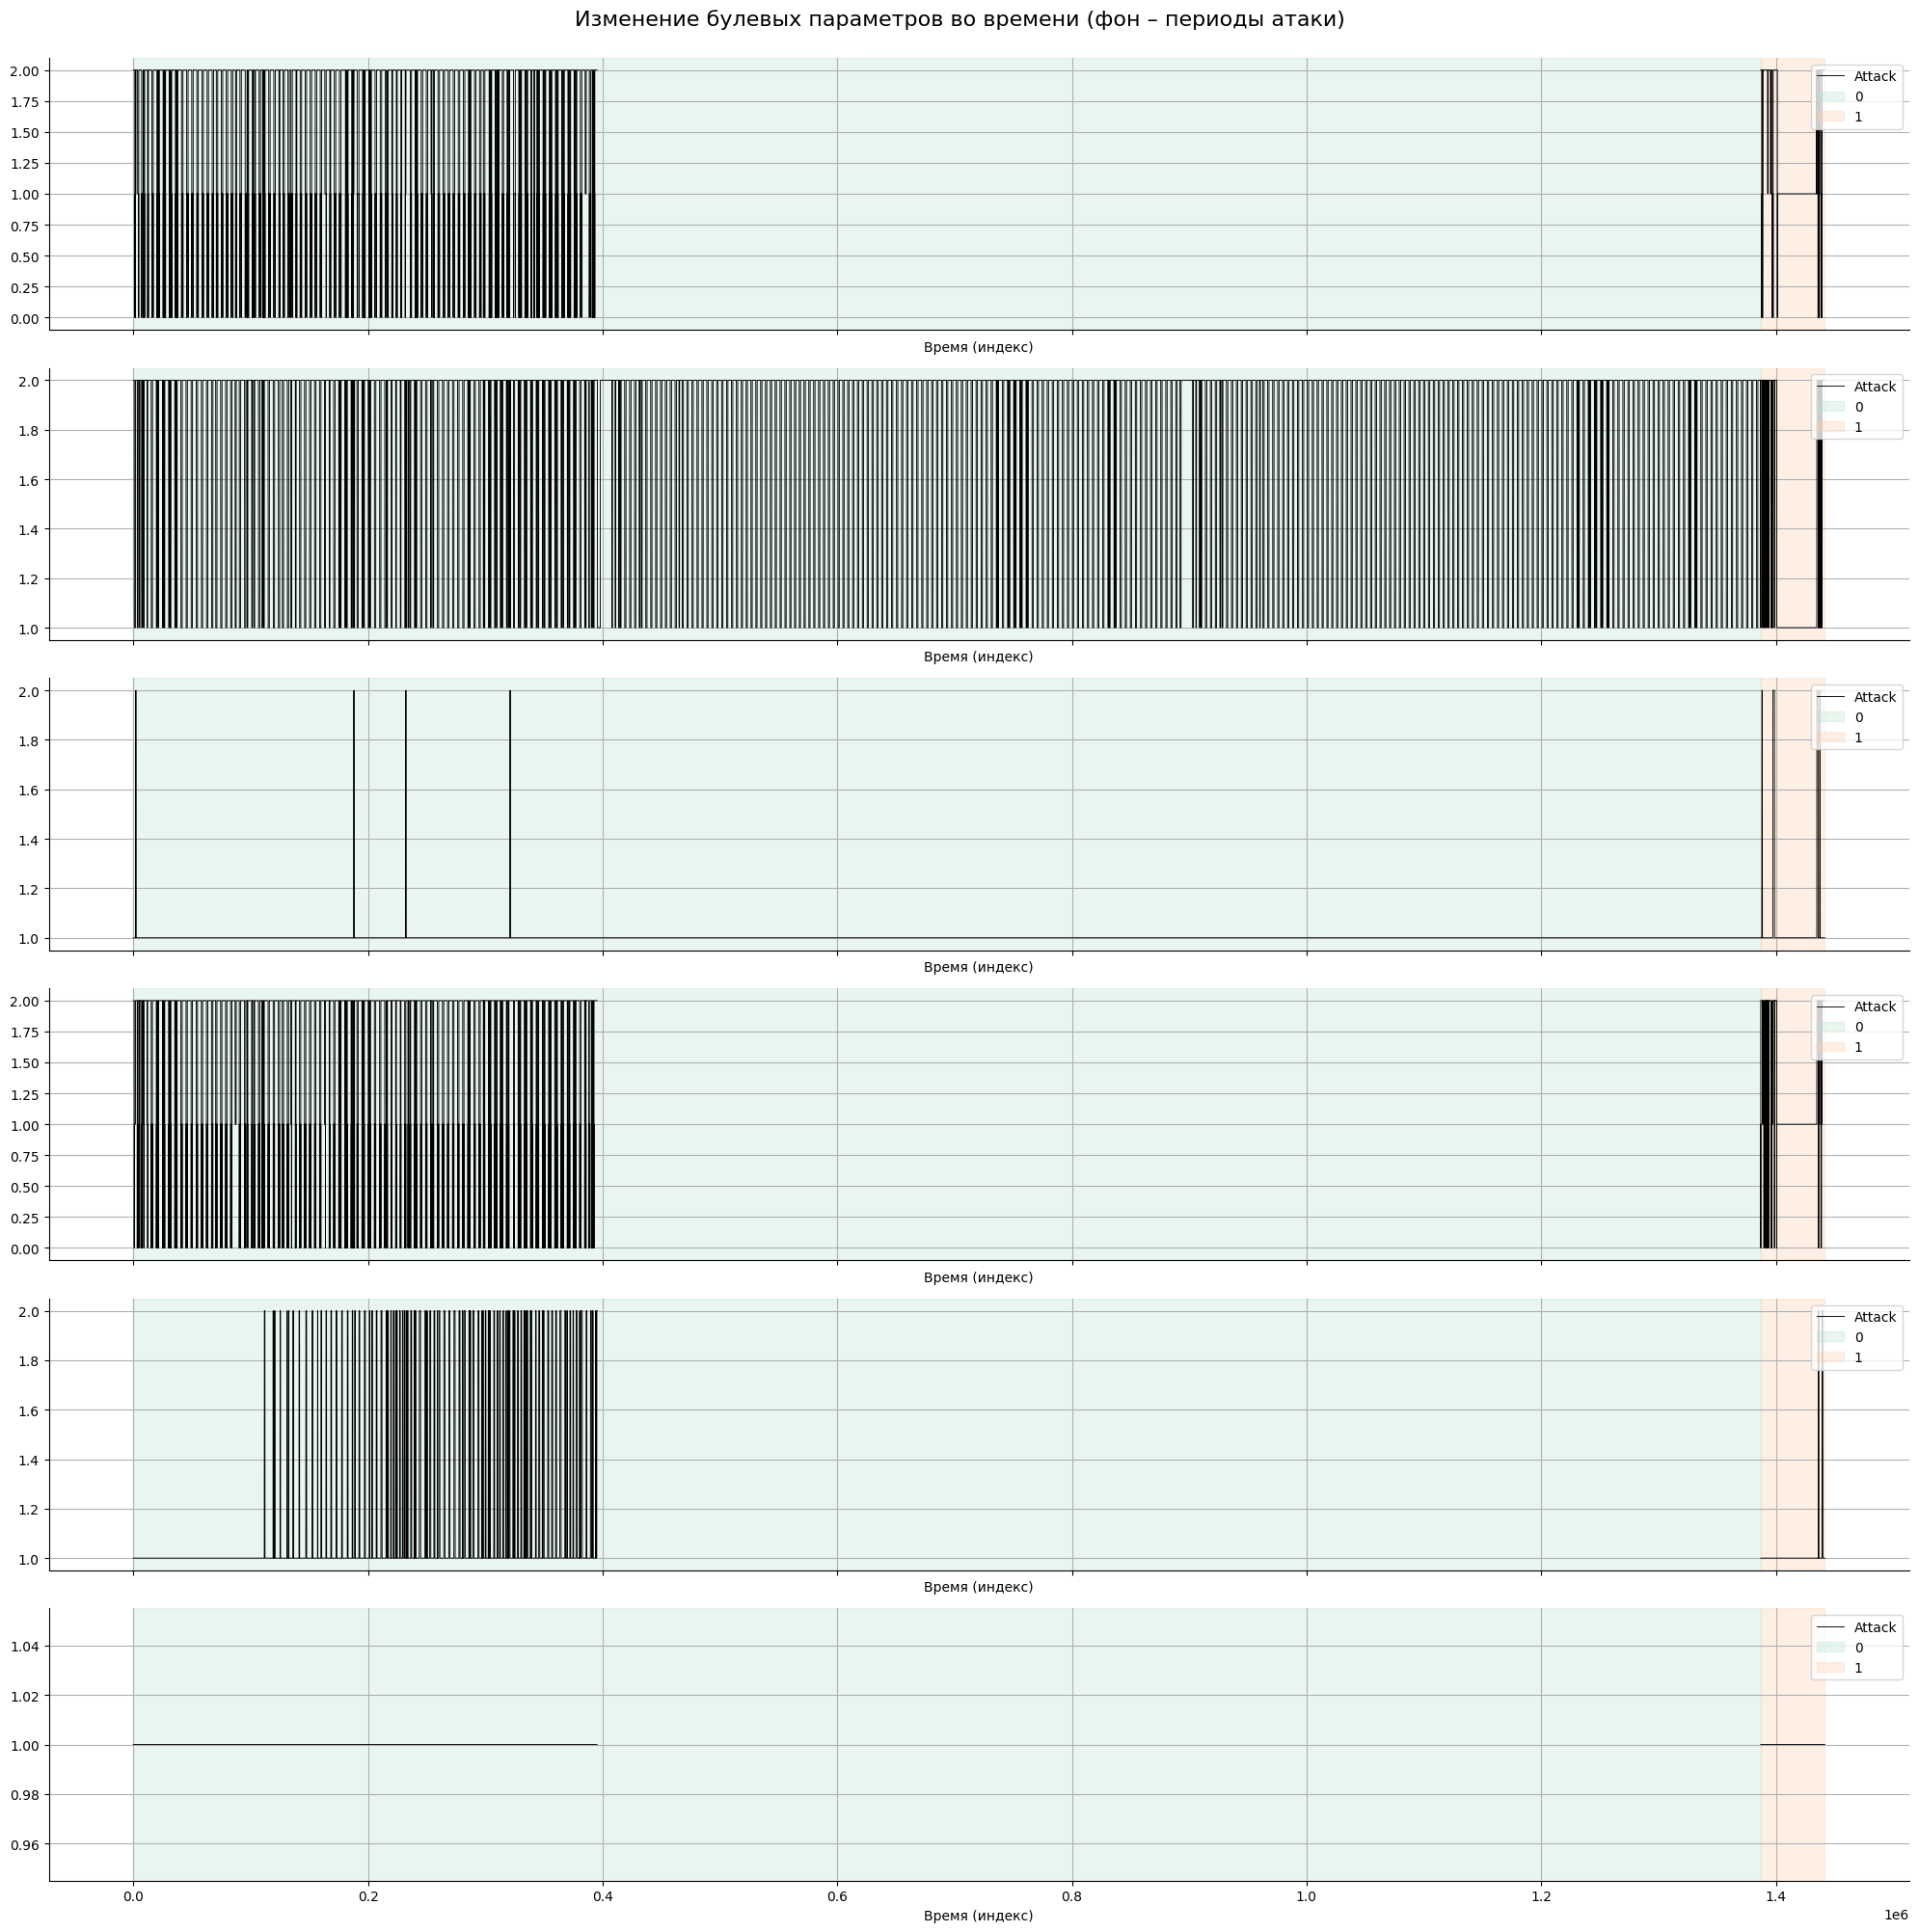

In [15]:
fig, ax = plt.subplots(nrows=6, ncols=1, sharex=True, figsize=(20, 20))

lineplot_for_atribute_set(df, x_axis, df['isAttack'], bool_labels1, ax)

plt.suptitle('Изменение булевых параметров во времени (фон – периоды атаки)', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

Из шести рассмотренных параметров (клапаны и насосы) пять показали значительные изменения в распределении состояний во время атаки:

- **MV101, MV201** – в норме чаще всего находятся в состоянии 2 (полностью открыт?), при атаке преобладает состояние 1 (промежуточное/частично открыт).
- **P101** – в норме доминирует состояние 2, при атаке – состояние 1 (насос чаще выключен или работает в пониженном режиме).
- **P102** – в норме почти всегда состояние 1, при атаке появляется заметная доля состояния 2.
- **P201** – в норме примерно половина на половину, при атаке почти всегда состояние 1.
- **P202** – не реагирует на атаку, всегда в состоянии 1.

Таким образом, большинство исполнительных устройств меняют своё поведение при атаке, что может служить надёжным индикатором аномалий.

## 6. Двумерный анализ переменных

6.1 Матрица рассеяния (с прореживанием)


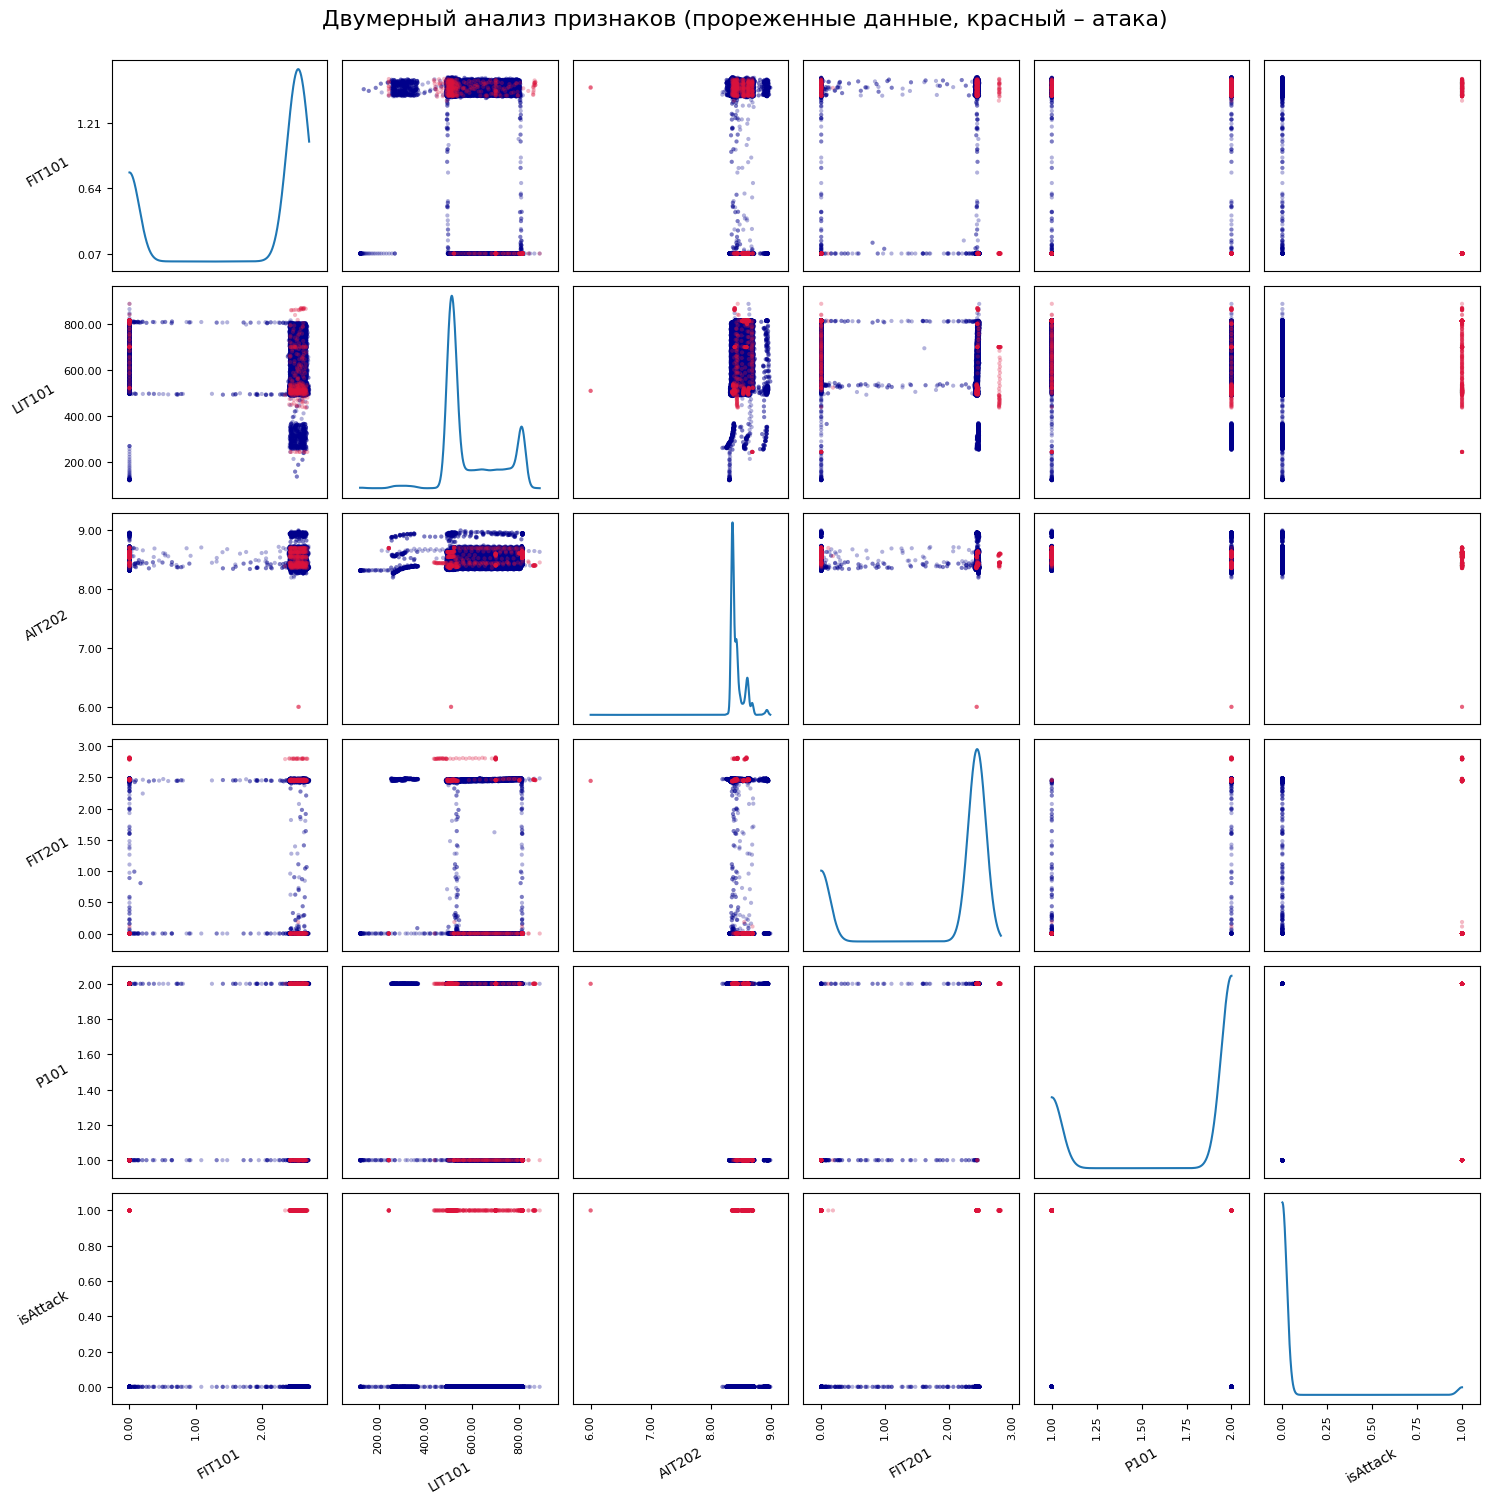

In [ ]:
# Прореживание с шагом (можно регулировать)
step = 50
df_sampled = df.iloc[::step].copy()
colors = ['#DC143C' if x else '#00008B' for x in df_sampled['isAttack']]

scatter_features = ['FIT101', 'LIT101', 'AIT202', 'FIT201', 'P101', 'isAttack']

axes = scatter_matrix(df_sampled[scatter_features], alpha=0.3, figsize=(15, 15),
                      range_padding=0.2, diagonal='kde', color=colors)
plt.suptitle('Двумерный анализ признаков (прореженные данные, красный – атака)', fontsize=16, y=1.00)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(30)
    ax.yaxis.label.set_rotation(30)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.show()

6.2 Корреляционная матрица


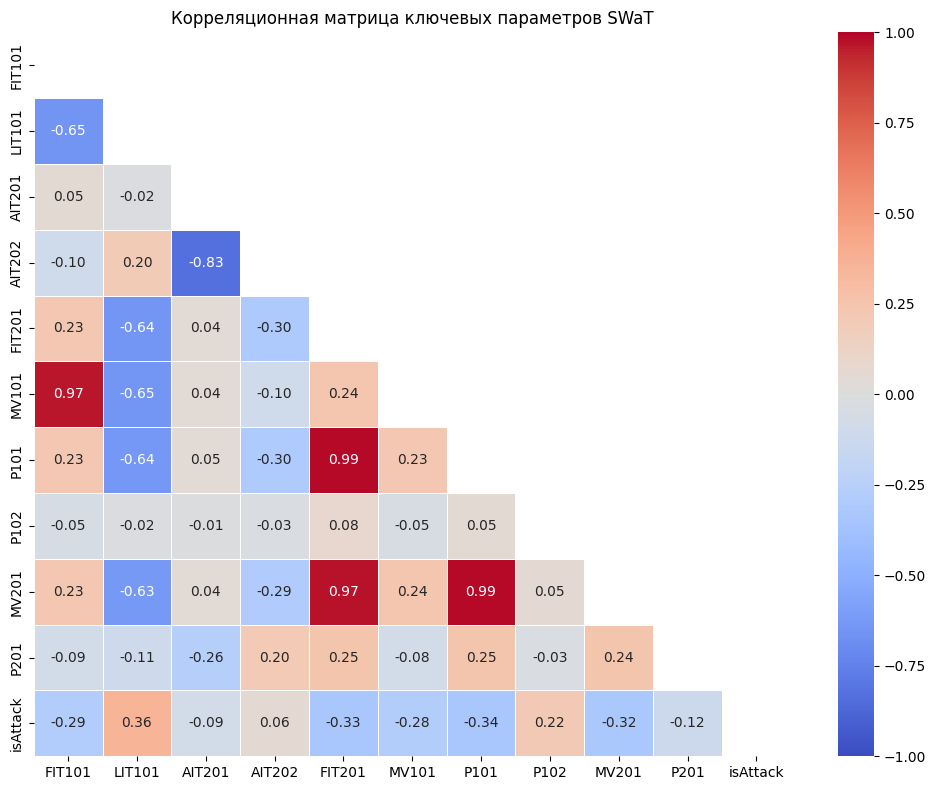

In [ ]:
corr_features = ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'FIT201',
                 'MV101', 'P101', 'P102', 'MV201', 'P201', 'isAttack']

df_corr = df[corr_features].dropna()

def heatmap(df, ax, title):
    corr = df.corr()
    mask = np.triu(np.ones_like(corr))
    sns.heatmap(corr, cbar=True, mask=mask, ax=ax, annot=True, cmap='coolwarm',
                vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap(df_corr, ax, 'Корреляционная матрица ключевых параметров SWaT')
plt.tight_layout()
plt.show()

На матрицах рассеяния и корреляций подтверждаются ранее выявленные закономерности:

- FIT101 и FIT201 имеют ярко выраженную отрицательную корреляцию с LIT101 (–0.65), а также сильную положительную связь друг с другом и с состояниями насосов P101, MV201 (корреляции около 0.96–0.99). Это отражает согласованную работу расходомеров и насосов.
- LIT101 отрицательно коррелирует практически со всеми признаками, связанными с расходом и насосами, что естественно: чем выше уровень, тем меньше поток.
- AIT201 и AIT202 имеют очень сильную отрицательную корреляцию (–0.83), что указывает на их противоположное поведение (вероятно, разные химические показатели).
- isAttack (метка атаки) наиболее сильно положительно коррелирует с LIT101 (0.36) и AIT202 (0.06), а отрицательно – с P101 (–0.34), FIT201 (–0.33), MV201 (–0.32), FIT101 (–0.29). Это значит, что при атаке уровень воды растёт, а расход и активность насосов падают, что полностью согласуется с анализом временных рядов.

## 7. Многомерный анализ признаков (PCA)

Метод главных компонент применён к 10 признакам (вещественным и логическим) после удаления пропусков.



Explained variance ratios: [0.4049474  0.19347485 0.18552438]
Total explained variance: 0.784


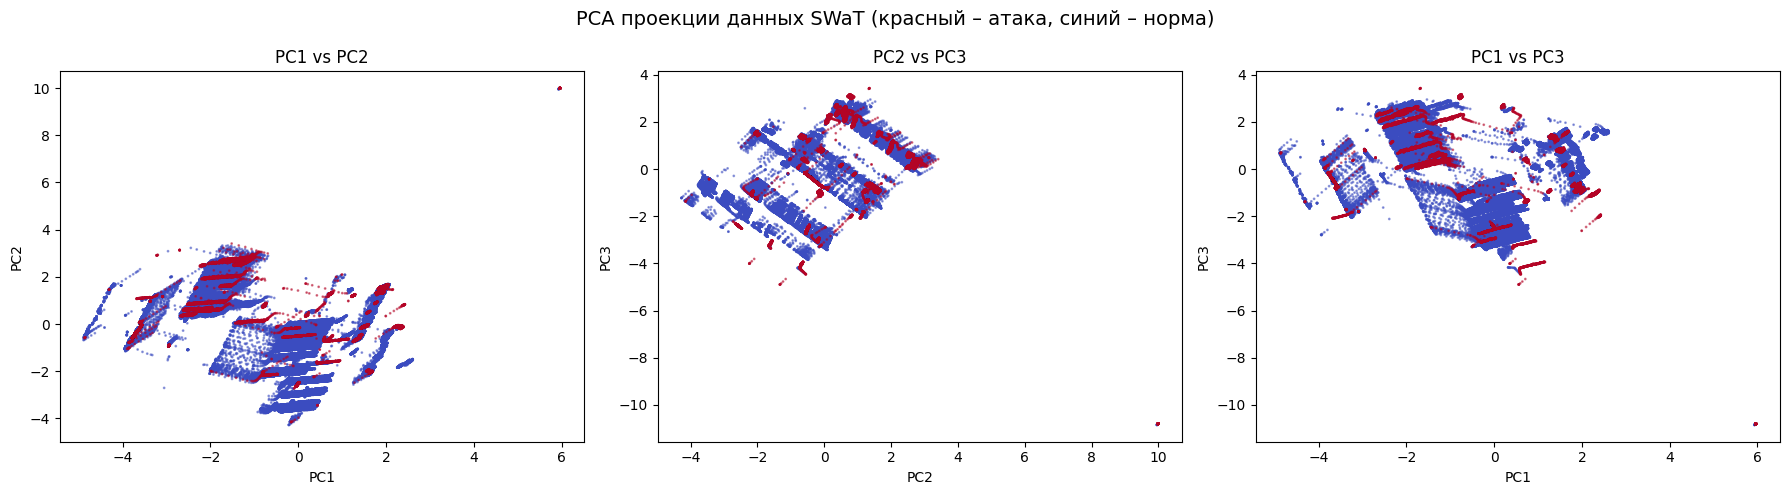

In [21]:
# Многомерный анализ: PCA для выбранных признаков
pca_features = ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'FIT201', 
                'MV101', 'P101', 'P102', 'MV201', 'P201']

# Удалим строки с пропусками для корректного PCA
df_pca = df[pca_features + ['isAttack']].dropna()

X = df_pca[pca_features].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
principal_components = pca.fit_transform(X_scaled)
print(f'Explained variance ratios: {pca.explained_variance_ratio_}')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum():.3f}')

principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle('PCA проекции данных SWaT (красный – атака, синий – норма)', fontsize=14)

# PC1 vs PC2
axes[0].scatter(principal_df['PC1'], principal_df['PC2'], 
                c=df_pca['isAttack'], cmap='coolwarm', s=1, alpha=0.5)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PC1 vs PC2')

# PC2 vs PC3
axes[1].scatter(principal_df['PC2'], principal_df['PC3'], 
                c=df_pca['isAttack'], cmap='coolwarm', s=1, alpha=0.5)
axes[1].set_xlabel('PC2')
axes[1].set_ylabel('PC3')
axes[1].set_title('PC2 vs PC3')

# PC1 vs PC3
axes[2].scatter(principal_df['PC1'], principal_df['PC3'], 
                c=df_pca['isAttack'], cmap='coolwarm', s=1, alpha=0.5)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC3')
axes[2].set_title('PC1 vs PC3')

plt.tight_layout()
plt.show()

Метод главных компонент (PCA) применён к 10 ключевым параметрам (расходы, уровни, анализаторы, насосы и клапаны). Первые три компоненты объясняют 78.4% общей дисперсии (PC1 – 40.5%, PC2 – 19.3%, PC3 – 18.6%). Это означает, что трёхмерная проекция достаточно хорошо сохраняет структуру данных, но около 22% информации теряется.

Анализ нагрузок показывает:

- PC1 противопоставляет расход (FIT101, FIT201, P101, MV201) и уровень (LIT101). При высоком расходе уровень падает, и наоборот.
- PC2 отражает вариации химических показателей (AIT201, AIT202) и насоса P201.
- PC3 комбинирует расход и анализатор AIT202.

На проекциях наблюдается некоторое разделение нормальных данных и атак, особенно в плоскости PC1–PC2. Однако из-за неполной объяснённой дисперсии полное разделение не достигается, но PCA подтверждает, что комбинация измерений содержит полезную для обнаружения атак информацию.

## 8. Ответы на контрольные вопросы


1. **Присутствуют ли в данных выбросы, и если да, то в каких атрибутах?**  
   Да, выбросы присутствуют. На ящиках с усами (раздел 3.2) видны выбросы для LIT101 (как вниз, так и вверх) и для AIT202 (в основном вверх при атаках). В FIT101 и FIT201 выбросов практически нет, так как их значения ограничены физическими пределами.

2. **Наблюдается ли переходный период выхода системы на стационарный режим?**  
   На временных рядах (раздел 4) не наблюдается явного переходного периода в начале данных – система сразу работает в установившемся режиме. Единственный длительный период атаки начинается примерно с индекса 1 300 000 и длится до конца, но это не переходный процесс, а целенаправленная атака.

3. **Какие атрибуты наиболее информативны для решения задачи классификации атак и почему?**  
   Наиболее информативны:
   - **FIT101, FIT201** – при атаке их значения резко падают до нуля (отключение потока).
   - **LIT101** – уровень воды устойчиво повышается во время атаки.
   - **AIT202** – незначительно, но стабильно повышается.
   - **P101, P102, MV101, MV201** – меняют распределение состояний (переключение режимов).
   
   Эти выводы подтверждаются как одномерными гистограммами, так и корреляционным анализом (метка атаки значимо коррелирует с перечисленными признаками).